In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.08563697872906924, 0.9730285714285715)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.29059749640822413, 0.9049)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.975250
automobile    0.985183
bird          0.969634
cat           0.943016
deer          0.973331
dog           0.949000
frog          0.986984
horse         0.977071
ship          0.988235
truck         0.981772
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 5, 2, 4]

In [17]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                        if(softmax.max()<split_mode[2]):
                            indexF.append(idx.cpu().numpy().item())

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [6,4,7,2]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [6,4,7,2]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('softmax',0.98,0.99)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(10855, 26109)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3773, 6711)

In [20]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [21]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [22]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [23]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.2144233226094927,train_accu=0.9211428571428572
Epoch=0,valid_loss=0.27446678354740145,valid_accu=0.8835
0
Epoch=1,train_loss=0.1559129482320377,train_accu=0.9449142857142857
Epoch=1,valid_loss=0.3151855167388916,valid_accu=0.8775
Epoch=2,train_loss=0.1033900169636522,train_accu=0.9673714285714285
Epoch=2,valid_loss=0.33540081639289854,valid_accu=0.8775
Epoch=3,train_loss=0.06091850354926927,train_accu=0.9854285714285714
Epoch=3,valid_loss=0.34364682950973513,valid_accu=0.8813
Epoch=4,train_loss=0.041661542311310765,train_accu=0.9896571428571429
Epoch=4,valid_loss=0.3751251656413078,valid_accu=0.8807
4 Early stopping!


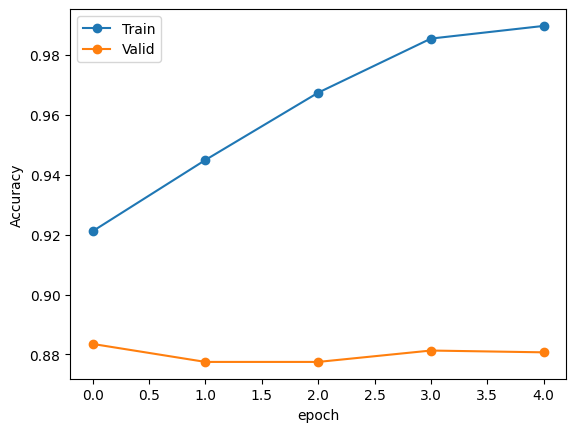

In [24]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

In [25]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.012928273363448957,train_accu=0.9963614079436209
Epoch=0,valid_loss=0.10149055329006987,valid_accu=0.985844136492326
0
Epoch=1,train_loss=0.005031655730006822,train_accu=0.9986211651154774
Epoch=1,valid_loss=0.1096332776037165,valid_accu=0.9867381910296528
0
Epoch=2,train_loss=0.0057795787757777,train_accu=0.9985062622084339
Epoch=2,valid_loss=0.11653031012388435,valid_accu=0.9886753091938608
0
Epoch=3,train_loss=0.0016015846475615281,train_accu=0.9996169903098548
Epoch=3,valid_loss=0.10716707558127572,valid_accu=0.9891223364625242
0
Epoch=4,train_loss=0.0029082743746209156,train_accu=0.9991190777126662
Epoch=4,valid_loss=0.13413051767931825,valid_accu=0.9883772910147519
Epoch=5,train_loss=0.0011867545636599062,train_accu=0.9997318932168984
Epoch=5,valid_loss=0.12442469103415578,valid_accu=0.9886753091938608
Epoch=6,train_loss=0.001485072156430005,train_accu=0.9997318932168984
Epoch=6,valid_loss=0.12440799996508194,valid_accu=0.9870362092087618
Epoch=7,train_loss=0

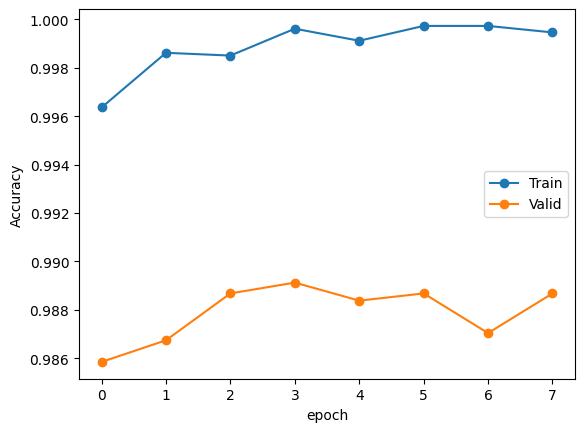

In [26]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.1679536258979417,train_accu=0.9461999078765546
Epoch=0,valid_loss=0.6662066139847538,valid_accu=0.7781606148953087
0
Epoch=1,train_loss=0.10928408039638533,train_accu=0.9690465223399355
Epoch=1,valid_loss=0.6853574188482909,valid_accu=0.7805459846276173
0
Epoch=2,train_loss=0.07164294743444556,train_accu=0.979824965453708
Epoch=2,valid_loss=0.6739196506650512,valid_accu=0.7911476278823217
0
Epoch=3,train_loss=0.054221308025785,train_accu=0.9865499769691386
Epoch=3,valid_loss=0.702389855695093,valid_accu=0.7898224224754837
Epoch=4,train_loss=0.04025423501247994,train_accu=0.9897742975587287
Epoch=4,valid_loss=0.7397551146041421,valid_accu=0.7879671349059104
Epoch=5,train_loss=0.03444671508153014,train_accu=0.9907876554583142
Epoch=5,valid_loss=0.7688408453869561,valid_accu=0.78690697058044
Epoch=6,train_loss=0.02042037715716266,train_accu=0.9957623215108246
Epoch=6,valid_loss=0.7748452321686228,valid_accu=0.7866419294990723
4 Early stopping!


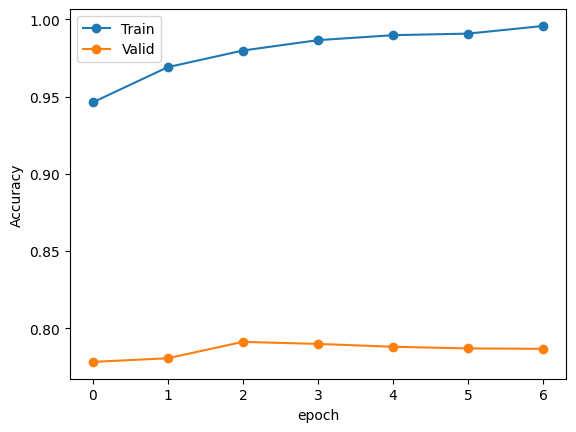

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.21451022994177682, 0.9238)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.27446678354740145, 0.8835)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0020270985181802524, 0.9995403883718258)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.07202876895950967, 0.9800092123445416)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.10948683943119535, 0.9888243182834153)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.6464110861682715, 0.7927378743705275)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.02148346749554455, 0.9944857142857143)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.32209325768351554, 0.9141, 3289)

In [36]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.0313121567999811, 0.9926285714285714, 10773, 24227)

In [37]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.3266113920807838, 0.9165, 3482, 6518)

In [38]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [39]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=('softmax', 0.98, 0.99)


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.085637,0.973029,0.290597,0.904900
1,Model_Decision,0.214510,0.923800,0.274467,0.883500
2,Model_T,0.002027,0.999540,0.109487,0.988824
3,Model_F,0.072029,0.980009,0.646411,0.792738
4,Total_Model,0.031312,0.992629,0.326611,0.916500
5,Total_Model_without_decision,0.021483,0.994486,0.322093,0.914100


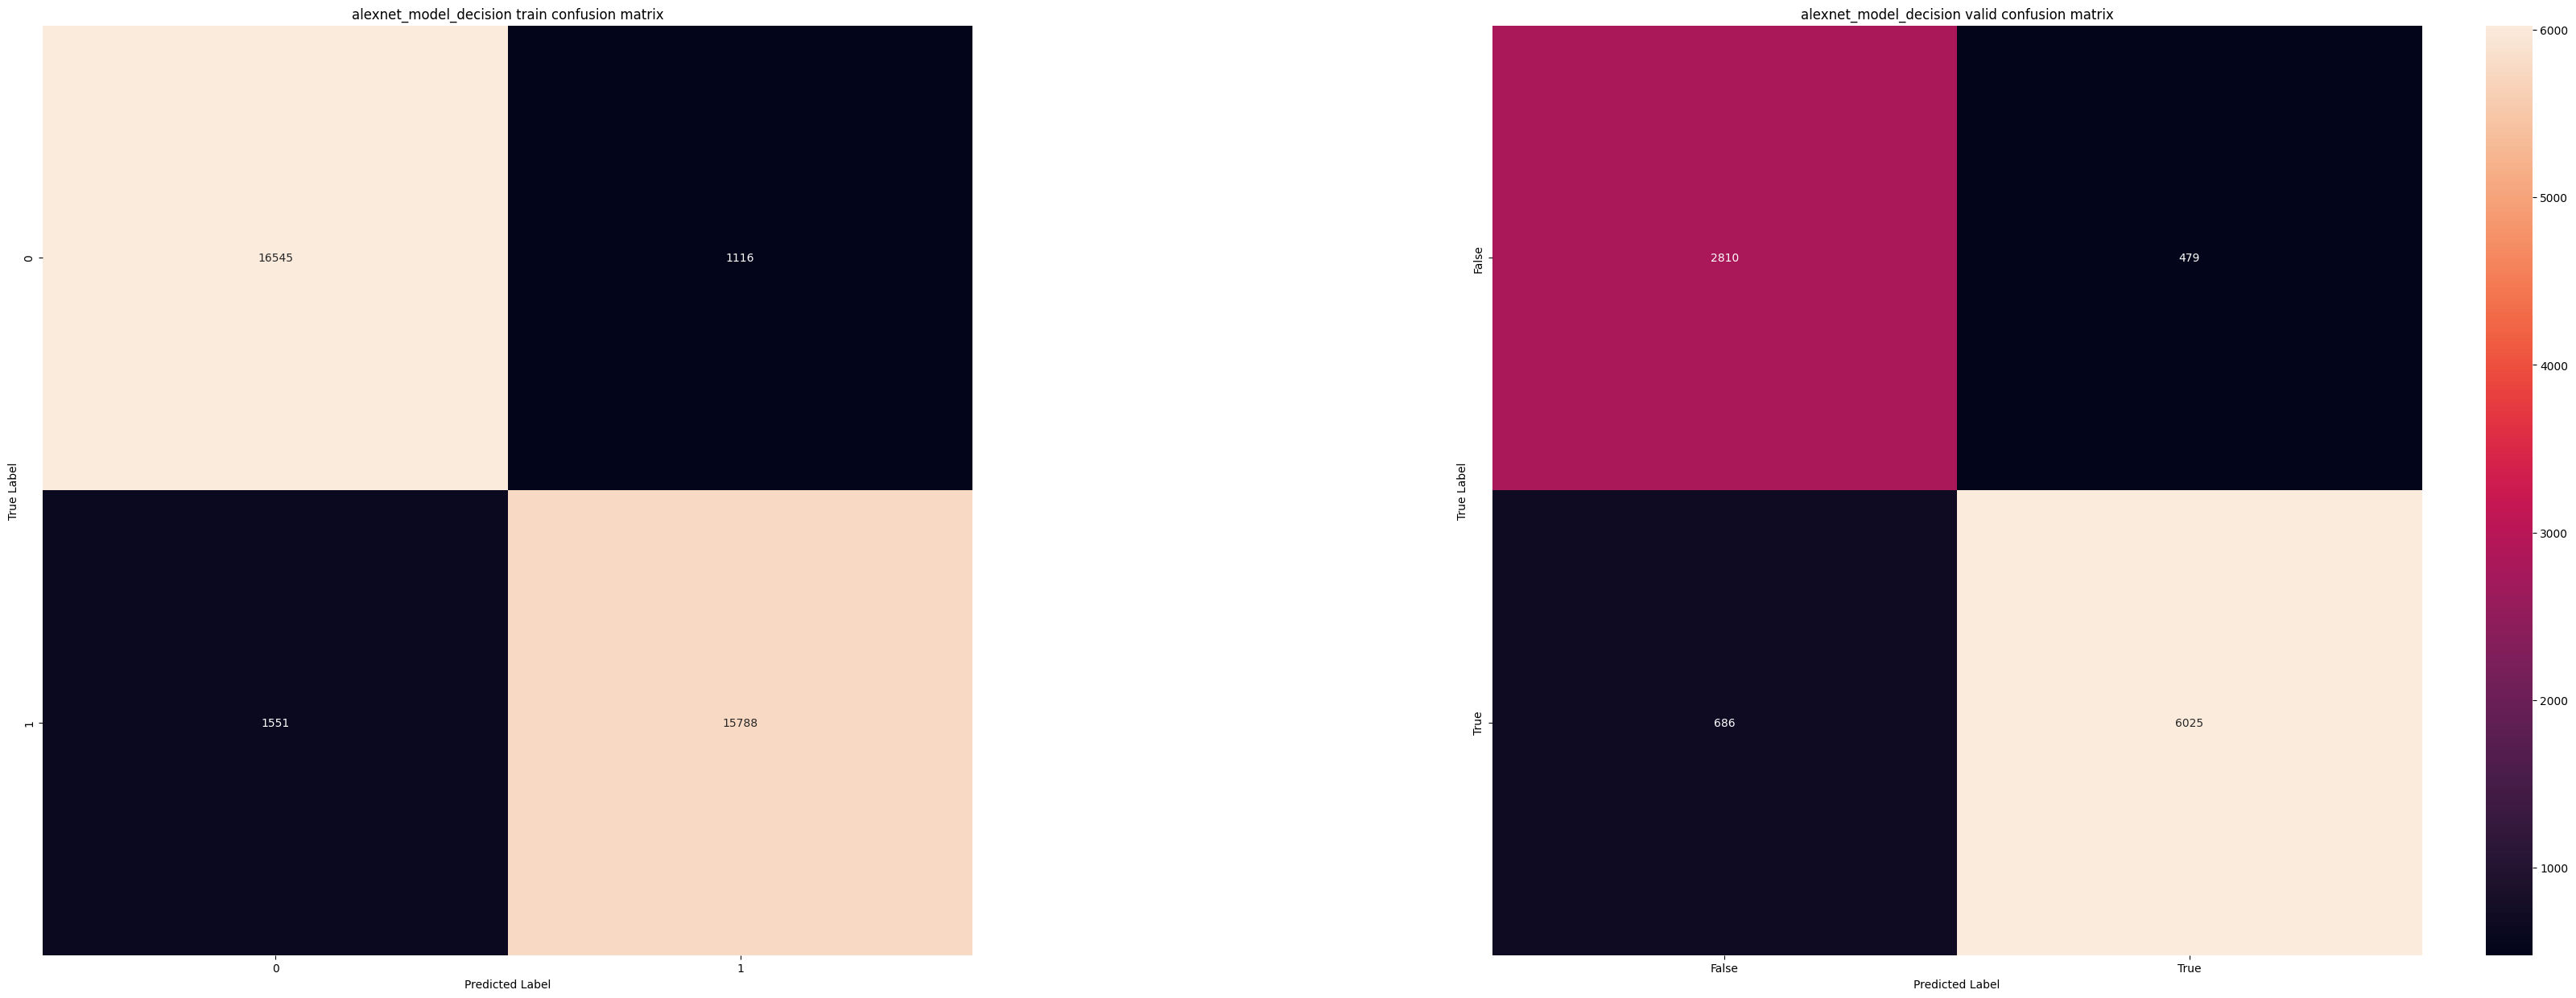

In [40]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

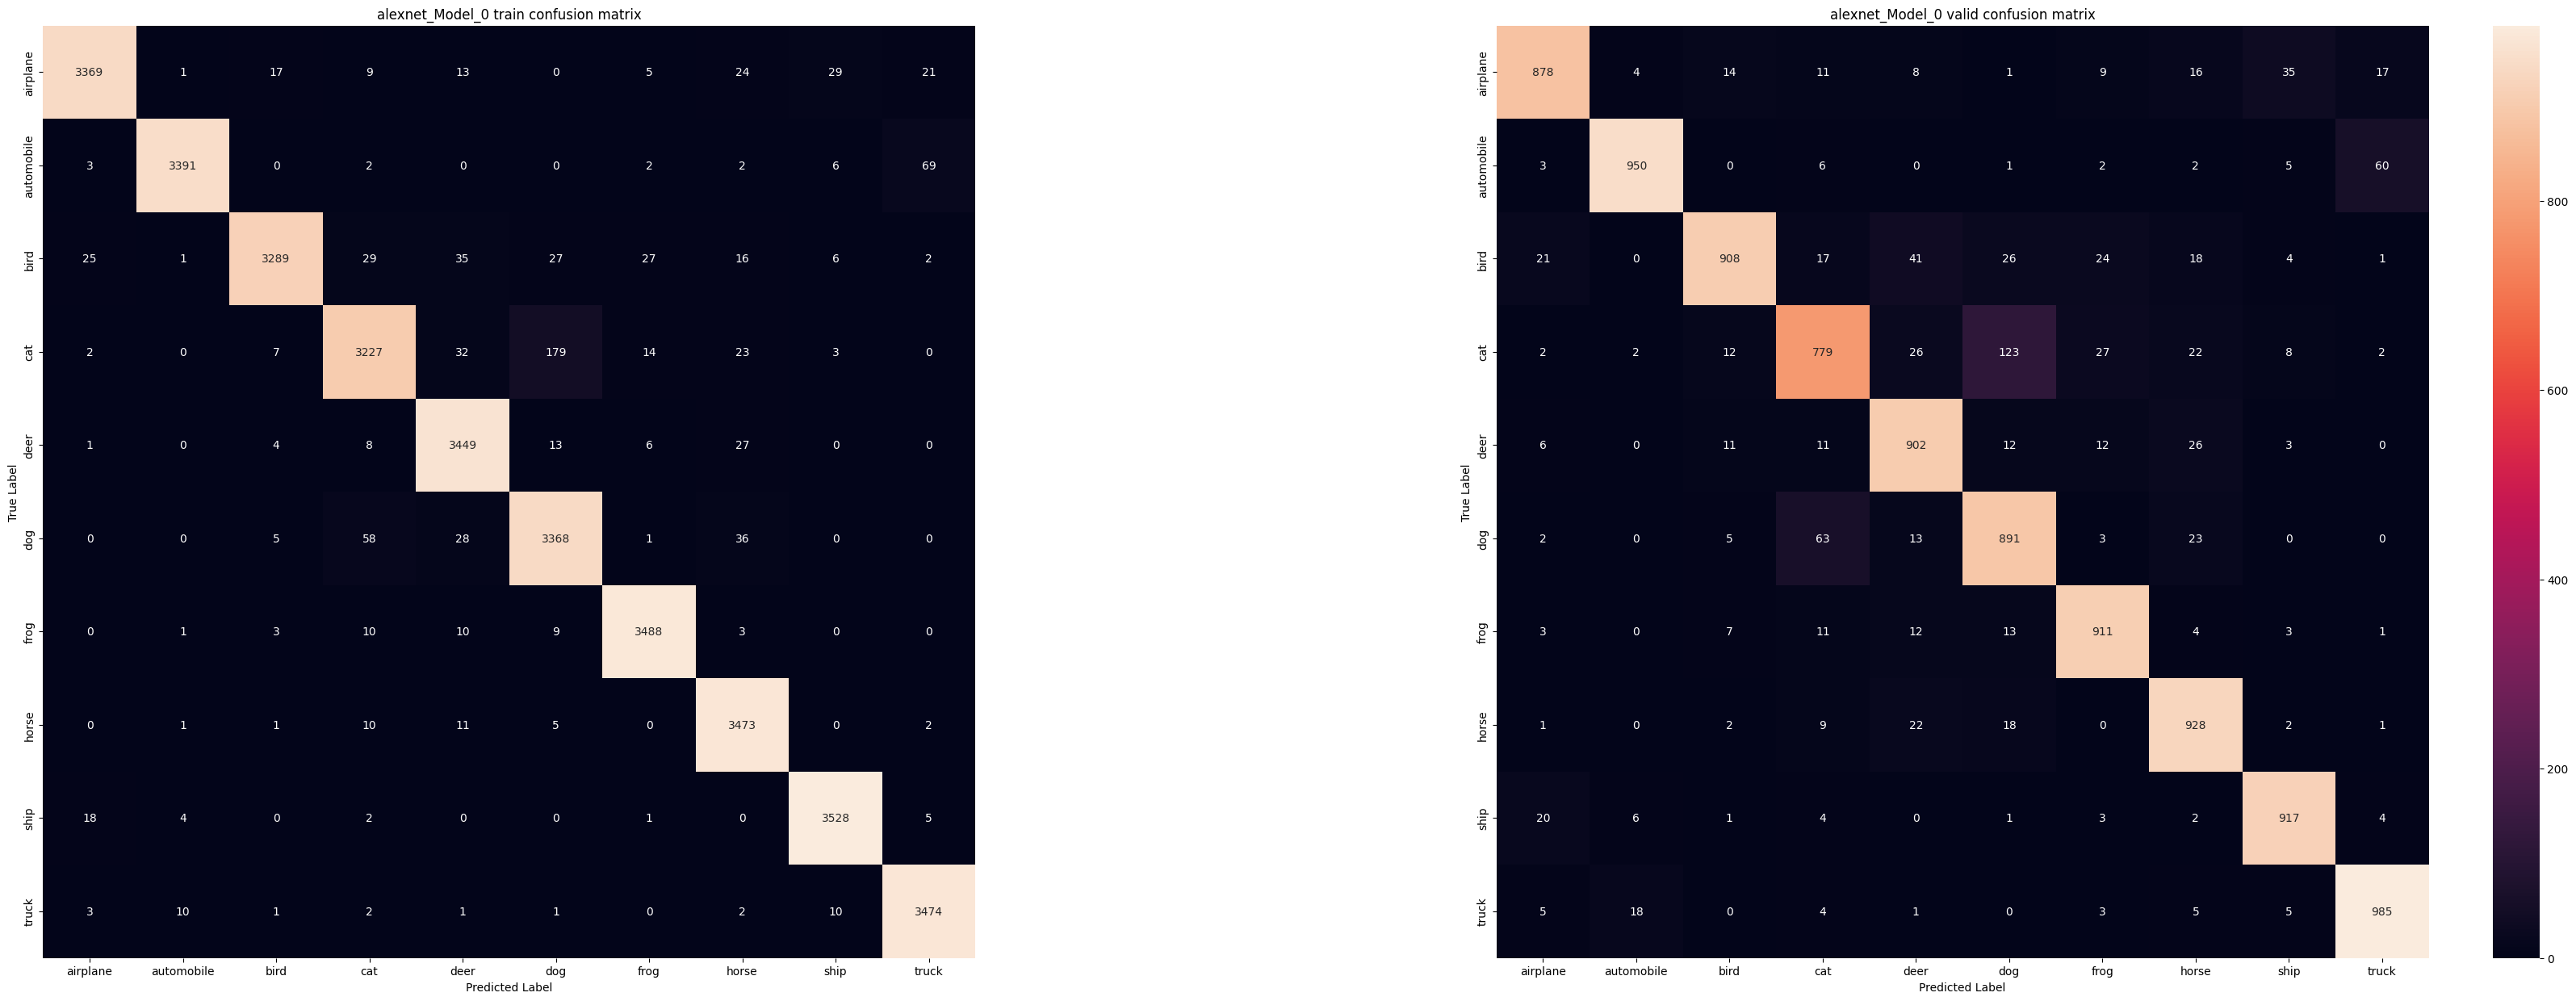

In [41]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [42]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [43]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.06792391 0.02271    0.01337324 0.01210556 0.01172483 0.01171497
 0.01145744 0.01126464 0.01083686 0.01039623 0.00945062 0.00924045
 0.00866155 0.00688073 0.00687681]
Top 15 Positions:
[(5, 3), (9, 1), (8, 0), (2, 0), (7, 5), (5, 4), (4, 3), (4, 2), (7, 4), (3, 2), (7, 3), (5, 2), (6, 2), (7, 0), (9, 0)]


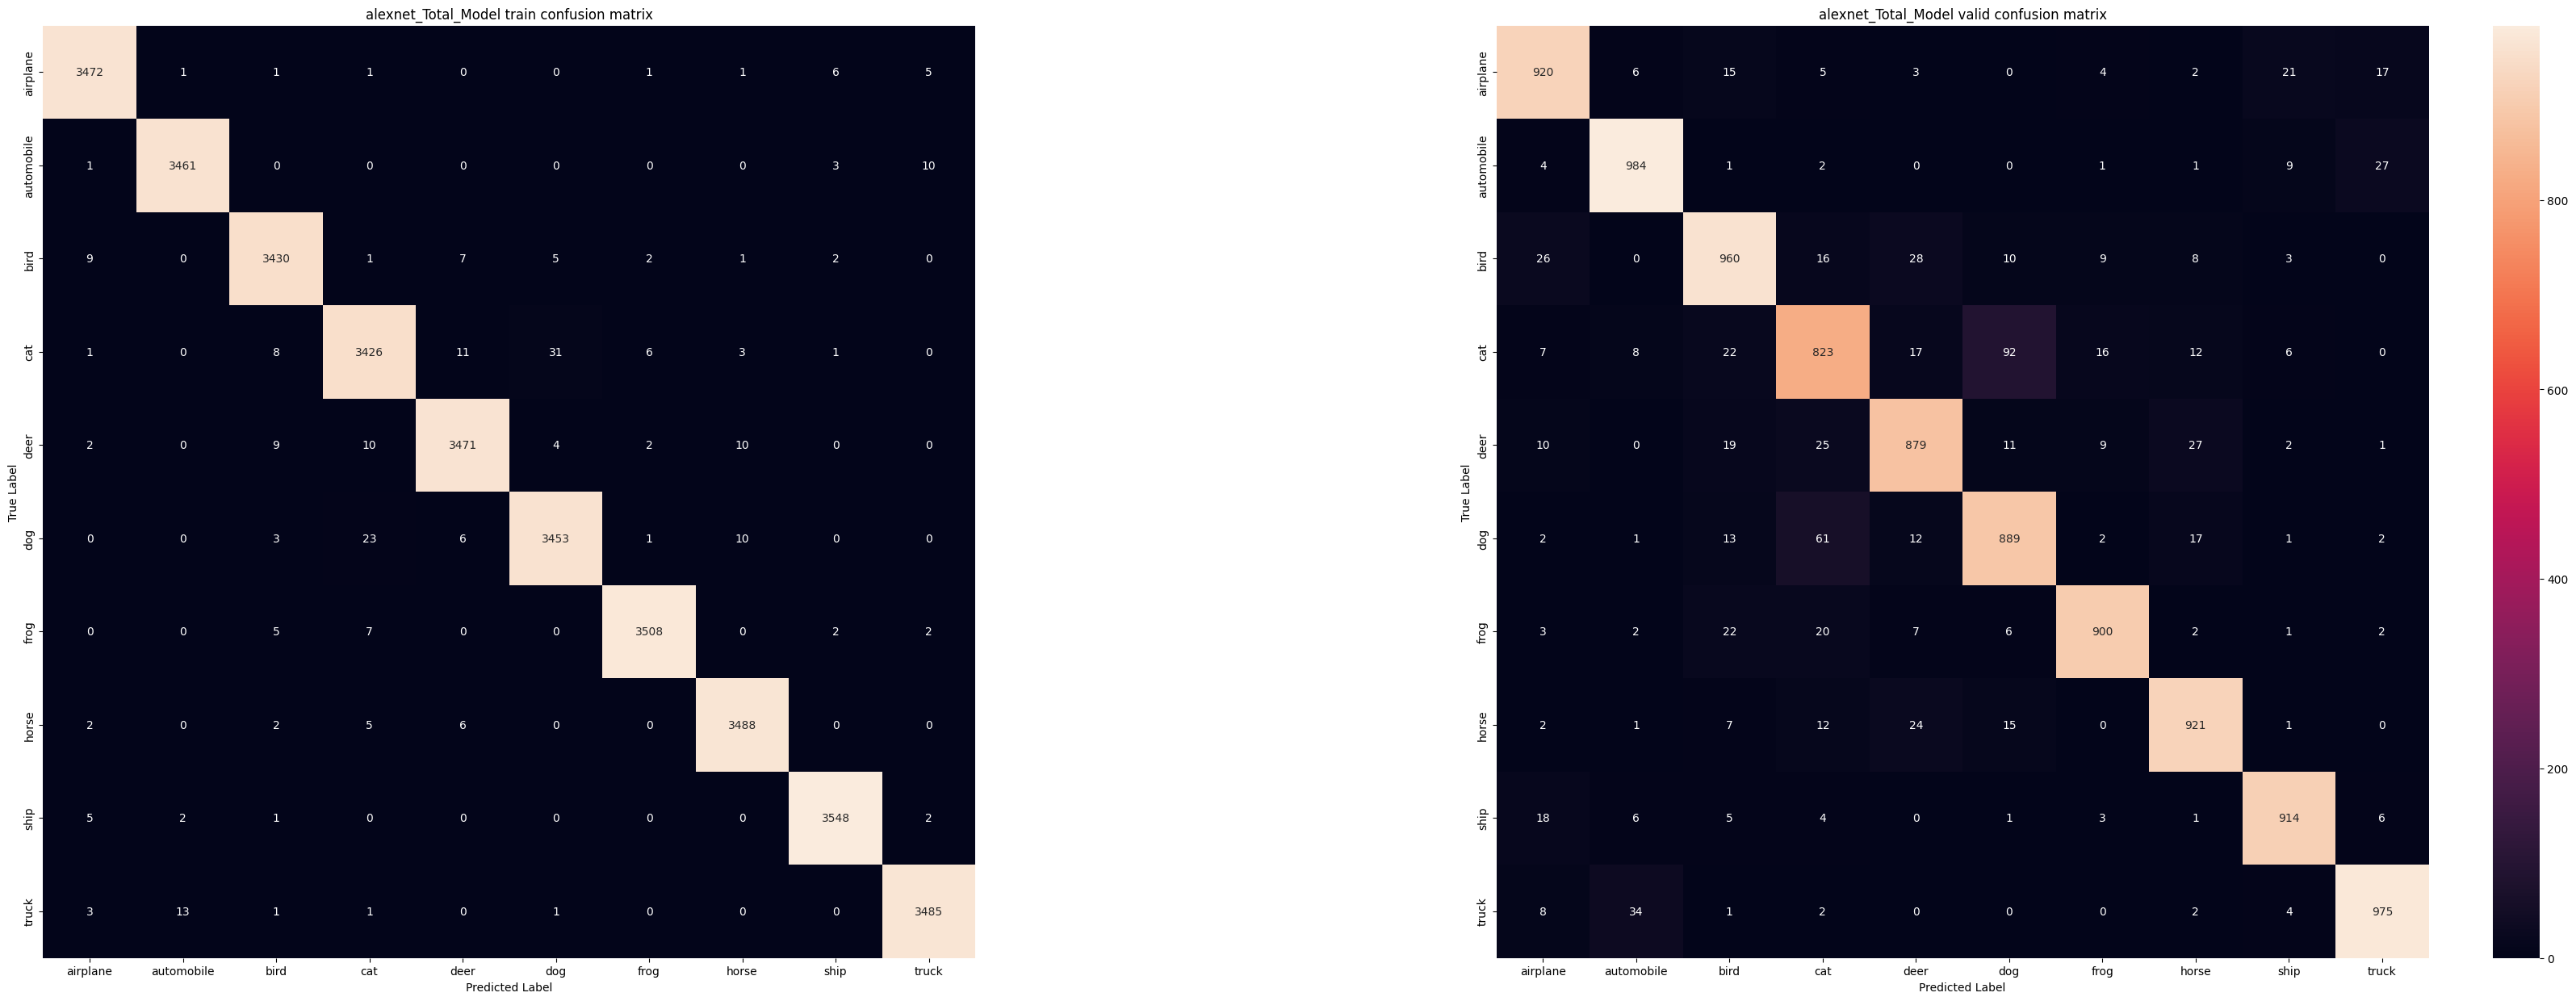

In [44]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

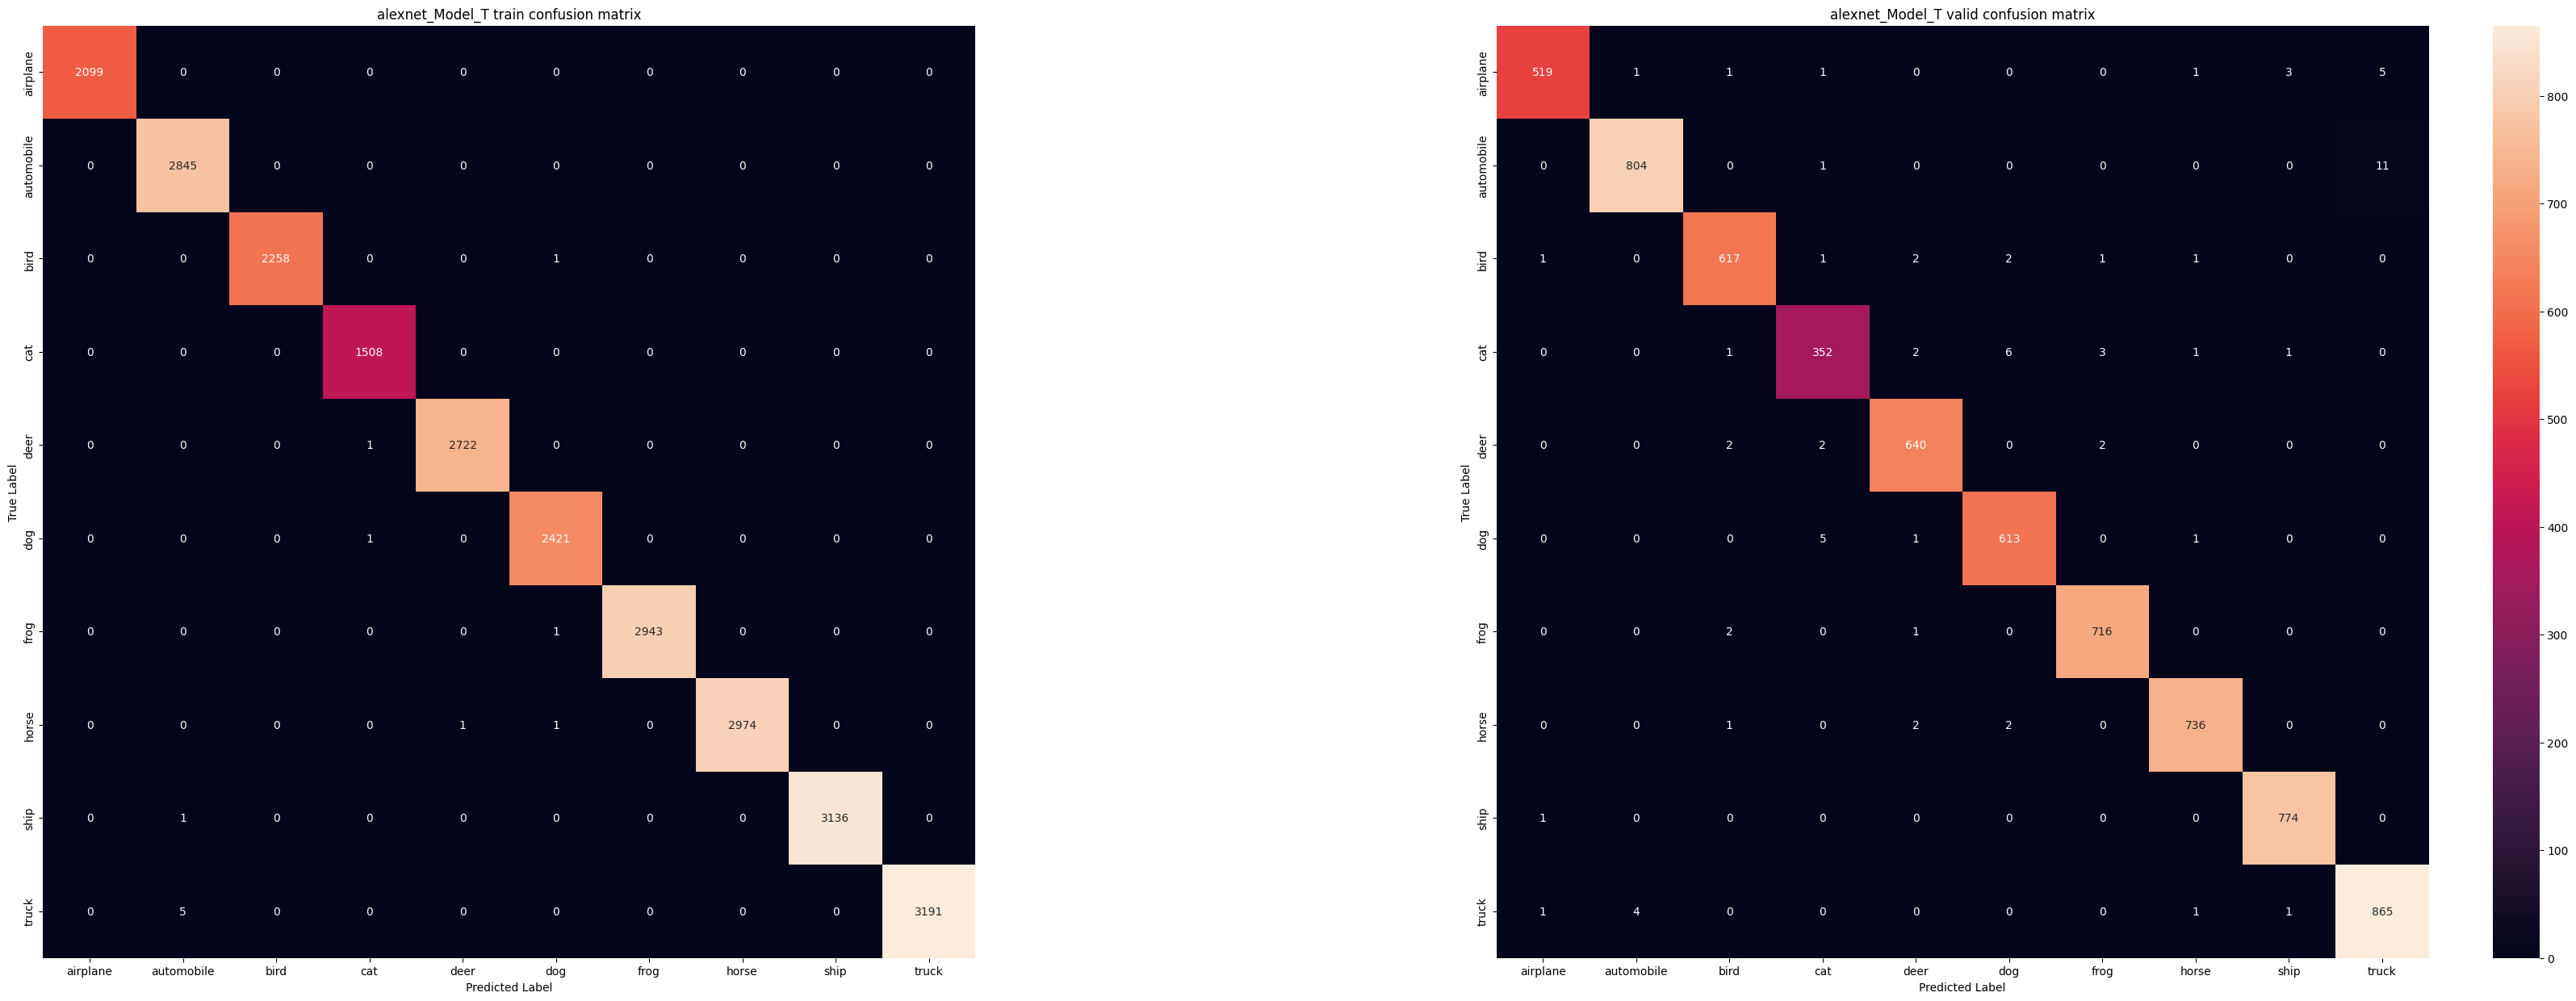

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

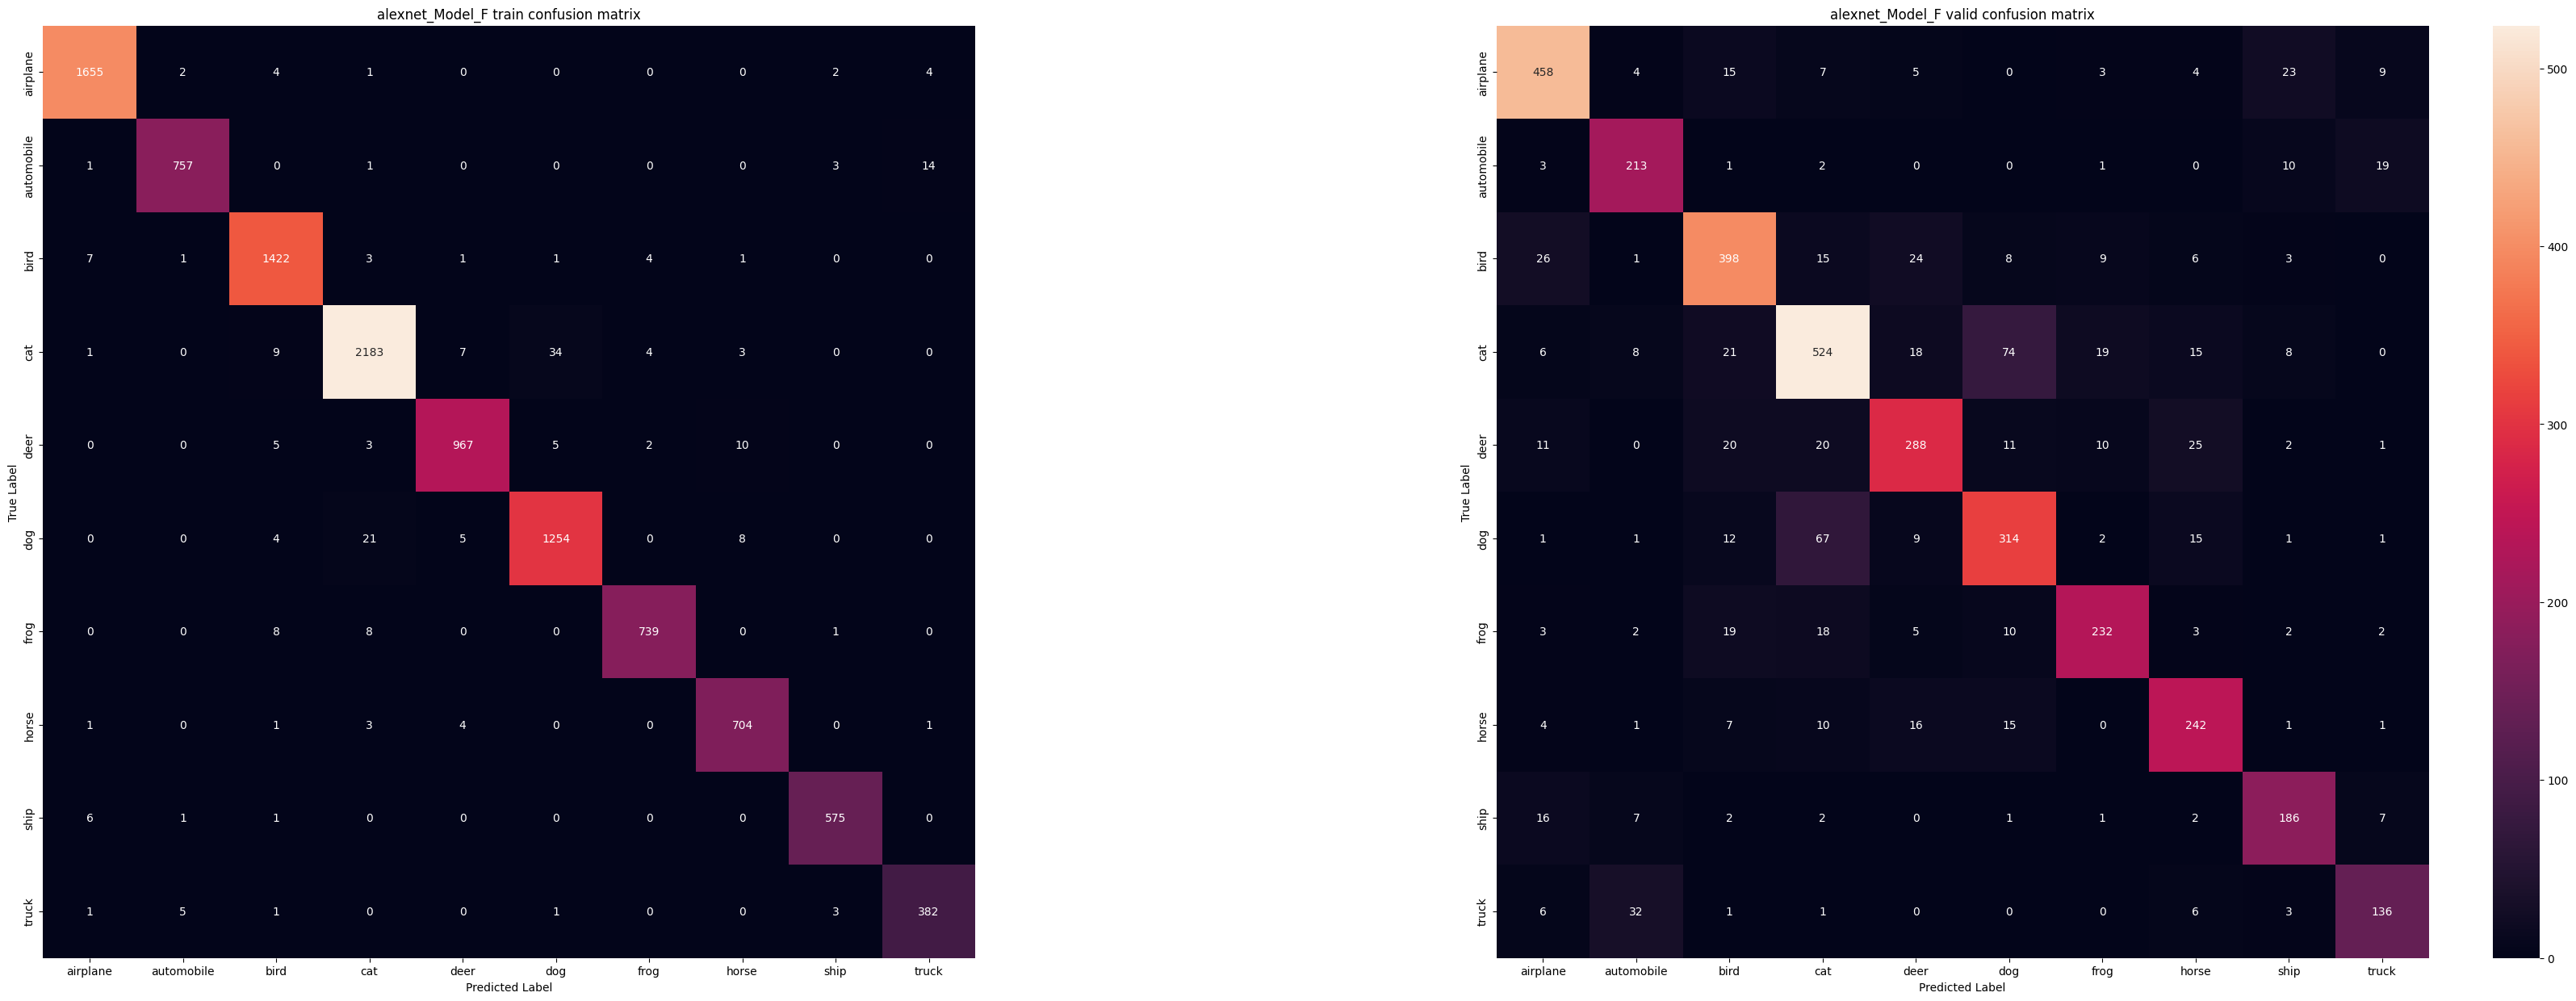

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [47]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [48]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,19695,2,2,2,2,0.999982,1.000000,0.999687,0.914634,True,True,True,True,True
1,18248,2,2,2,2,0.999959,1.000000,0.983580,0.700146,True,True,True,False,True
2,15144,2,6,2,6,0.765475,1.000000,0.584948,0.957036,False,True,False,True,True
3,20592,1,1,1,1,0.999998,1.000000,0.999998,0.999876,True,True,True,True,True
4,11668,3,3,3,3,0.999999,1.000000,0.999989,0.999997,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,1142,0,0,0,0,0.999862,0.999999,0.979013,0.570807,True,True,True,False,False
34996,787,2,2,2,2,0.999960,1.000000,0.995554,0.913926,True,True,True,False,False
34997,25265,5,5,5,5,0.984655,0.999515,0.993554,0.718910,True,True,True,True,True
34998,37727,1,1,1,1,0.999987,1.000000,0.997944,0.899915,True,True,True,True,True


In [49]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1,18248,2,2,2,2,0.999959,1.000000,0.983580,0.700146,True,True,True,False,True
12,19126,3,3,3,3,0.999929,0.999999,0.996729,0.620855,True,True,True,False,True
13,16209,3,3,3,3,0.999771,1.000000,0.984323,0.563889,True,True,True,True,False
18,47723,8,8,8,8,0.849469,0.999990,0.990809,0.870791,True,True,True,False,True
26,48949,9,9,9,9,0.988081,0.977638,0.943483,0.665374,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34964,736,8,8,8,8,0.999883,0.999839,0.998744,0.551817,True,True,True,True,False
34967,36964,5,5,5,5,0.999680,1.000000,0.981047,0.512601,True,True,True,True,False
34982,37441,5,5,5,5,0.993529,0.999856,0.989679,0.723072,True,True,True,False,True
34984,2464,8,8,8,8,0.999958,1.000000,0.999568,0.676882,True,True,True,False,True


In [50]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

2    546
0    480
3    449
8    389
5    346
7    336
6    334
4    293
1    267
9    193
Name: Target, dtype: int64

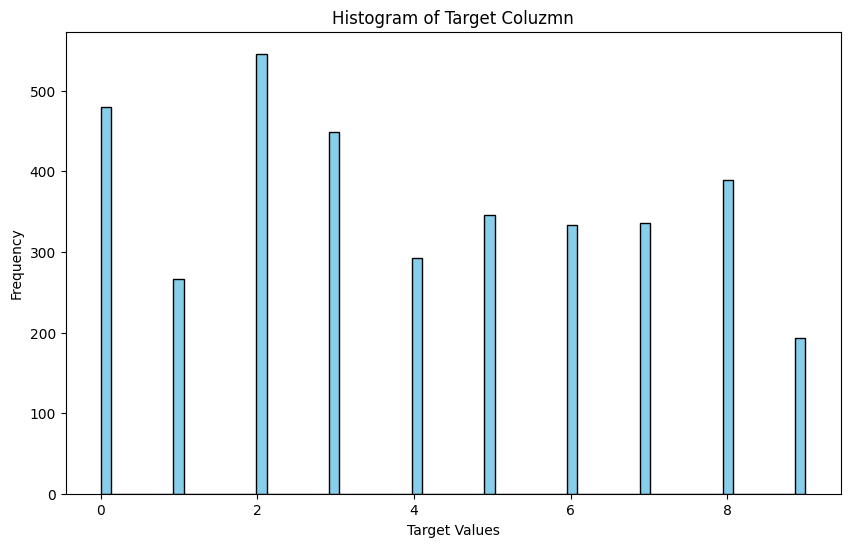

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [52]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,21772,4,4,4,4,0.999573,1.000000,0.998301,0.997105,True,True,True,True,True
1,49380,5,5,5,5,0.999996,1.000000,0.999328,0.999887,True,True,True,True,True
2,2989,6,6,6,6,0.999897,1.000000,0.998003,0.630833,True,True,True,False,True
3,44130,7,7,7,7,0.999402,0.999995,0.997027,0.914524,True,True,True,True,True
4,31693,0,0,0,0,0.825891,0.999751,0.834692,0.862452,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3030,4,4,4,4,0.999774,1.000000,0.997709,0.864044,True,True,True,True,False
9996,36723,0,0,0,0,0.999946,0.999998,0.994613,0.566898,True,True,True,True,True
9997,33617,0,0,0,0,0.898718,0.962274,0.550247,0.944969,True,True,True,False,False
9998,8345,7,7,7,7,0.999995,1.000000,0.999897,0.998795,True,True,True,True,True


In [53]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
2,2989,6,6,6,6,0.999897,1.000000,0.998003,0.630833,True,True,True,False,True
12,31584,3,3,3,3,0.999709,0.999997,0.966980,0.563702,True,True,True,True,False
14,37345,4,4,4,4,0.999871,0.999999,0.994771,0.912942,True,True,True,True,False
17,38028,1,1,1,1,0.999275,0.999990,0.991234,0.754177,True,True,True,False,True
24,737,2,2,2,2,0.999999,0.999975,0.996037,0.616936,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9952,26066,6,3,3,6,0.842538,0.889887,0.625149,0.948975,False,False,True,True,False
9985,48714,7,7,7,7,0.998701,1.000000,0.995738,0.891936,True,True,True,True,False
9986,34930,2,2,2,2,0.999796,0.999999,0.995234,0.817843,True,True,True,False,True
9989,12725,8,8,8,8,0.999997,1.000000,0.986835,0.540739,True,True,True,False,True


In [54]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

2    179
0    135
3    127
5    113
4    112
6    111
7    109
1    103
8     88
9     77
Name: Target, dtype: int64

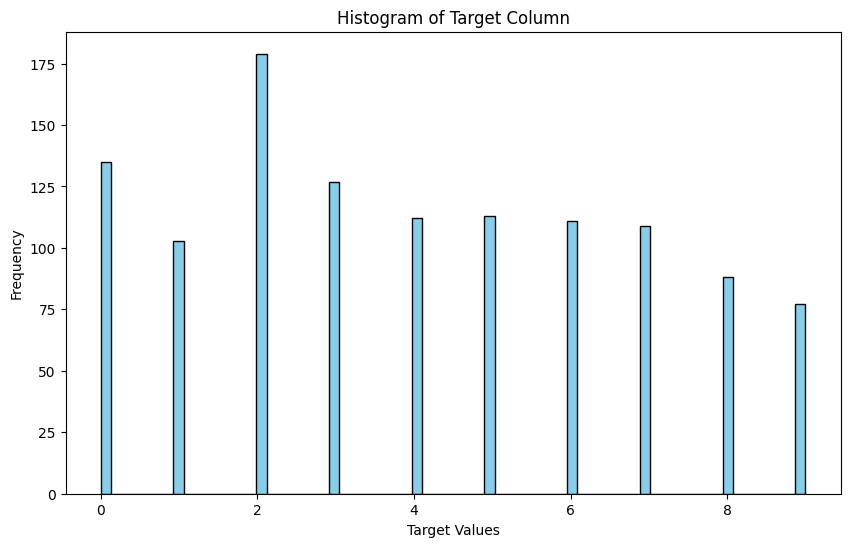

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [57]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.04538562331619074, 0.9910285714285715, 10626, 24374)

In [58]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.3732382855232805, 0.9154, 3225, 6775)

In [59]:
ALL=set(range(10))
targetT=list(ALL-set(targetF))

model_0_embed= copy.deepcopy(model_0)
# model_0_embed.classifier[5]=nn.Identity()
model_0_embed.classifier[6]=nn.Identity()

In [60]:
mean_features_dict_T = {class_idx: [] for class_idx in targetT}
for data, target, idx in Tdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx not in  targetF:
                mean_features_dict_T[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_T = {}
for class_idx, features_list in mean_features_dict_T.items():
    mean_features_T[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [61]:
mean_features_dict_F = {class_idx: [] for class_idx in targetF}
for data, target, idx in Fdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx in targetF:
                mean_features_dict_F[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_F = {}
for class_idx, features_list in mean_features_dict_F.items():
    mean_features_F[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [62]:
mean_features_F

{3: tensor([0.0016, 0.1209, 0.0000,  ..., 0.2137, 0.0212, 0.0004]),
 5: tensor([2.2269e-04, 1.7617e-01, 0.0000e+00,  ..., 5.2226e-01, 1.3067e-02,
         0.0000e+00]),
 2: tensor([0.0015, 0.1583, 0.0000,  ..., 0.0187, 0.0515, 0.0004]),
 4: tensor([0.0008, 0.0013, 0.0000,  ..., 0.0138, 0.0163, 0.0005])}

In [63]:
import torch.nn.functional as F
def calculate_sim_max_idx(f,mean_features):
    k=0
    max=0
    for i in mean_features.keys():
        sim=F.cosine_similarity(f,mean_features[i], dim=0)
        if(max<sim):
            k=i
            max=sim
    return k,max

In [64]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/train_size
sum_all

0.9850571428571429

In [65]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/valid_size
sum_all

0.9616

In [66]:
#全部模型裝在一起的表現
def total_model_cos_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
                k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)

                if(similarity_T>similarity_F):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [67]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.07220136761165091, 0.9810285714285715, 14010, 20990)

In [68]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.3722032182186842, 0.9115, 4073, 5927)

In [69]:
def choose_with_model(data):
    out_decision=model_decision(data)
    _, pred = torch.max(out_decision, dim = 1) 
    softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
    if(pred==0):
        return 0
    else:
        return 1

In [70]:
def choose_with_softmax(data):
    out_T = model_T(data)
    softmax_T=torch.softmax(out_T, dim=1)

    out_F = model_F(data)
    softmax_F=torch.softmax(out_F, dim=1)

    st_max=torch.max(softmax_T).item()
    sf_max=torch.max(softmax_F).item()

    if(sf_max>st_max):
        return 0
    else:
        return 1

In [71]:
def choose_with_sim(out,mean_features_T,mean_features_F):
    k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
    k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)
    if(similarity_T>similarity_F):
        return 1
    else:
        return 0


In [72]:
#全部模型裝在一起的表現
def total_model_decision_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
                soft_decision=choose_with_softmax(d.unsqueeze(0))
                mo_decision=choose_with_model(d.unsqueeze(0))
                total_decision=sim_decision+soft_decision+mo_decision

                if(total_decision>=2):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [73]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.04830693449015463, 0.9895428571428572, 7627, 27373)

In [74]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.3798939034618437, 0.916, 2340, 7660)

In [75]:
# 计算并打印每个数据点的平均边际效应
def calculate_ame_per_sample(model, data_loader, delta=1e-5):
    model.eval()
    ames = []
    idxs=[]
    with torch.no_grad():
        for inputs, _,idx in data_loader:
            inputs = inputs.to(device)
            base_preds = model(inputs).cpu().numpy()

            batch_ames = []
            
            for i in range(inputs.shape[1]):  # 对每个通道计算边际效应
                inputs_delta = inputs.clone()
                inputs_delta[:, i, :, :] += delta
                delta_preds = model(inputs_delta).cpu().numpy()
                ame = (delta_preds - base_preds) / delta
                batch_ames.append(ame)

            batch_ames = np.stack(batch_ames, axis=1)  # (batch_size, num_channels, num_classes)
            batch_ames = np.mean(batch_ames, axis=(1, 2))
            
            ames.append(batch_ames)
            idxs.extend(idx.cpu().numpy())

    ames = np.concatenate(ames, axis=0)  # (num_samples, num_channels, num_classes)
    return idxs,ames



In [76]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_F, Fdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.95 # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Fdataset = Subset(images, filter_idxs)
filtered_Fdl= DataLoader(filtered_Fdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.19111437264387696,train_accu=0.940166795965865
Epoch=0,valid_loss=0.672587669736158,valid_accu=0.7680890538033395
0
Epoch=1,train_loss=0.11726208057766094,train_accu=0.9657680372381692
Epoch=1,valid_loss=0.6627265971944846,valid_accu=0.7800159024648821
0
Epoch=2,train_loss=0.08036858508402382,train_accu=0.9778898370830101
Epoch=2,valid_loss=0.6941699872606476,valid_accu=0.7903525046382189
0
Epoch=3,train_loss=0.05248900477198596,train_accu=0.9887509697439876
Epoch=3,valid_loss=0.7313942311772483,valid_accu=0.7755102040816326
Epoch=4,train_loss=0.04310598900423171,train_accu=0.9904965089216446
Epoch=4,valid_loss=0.7348597752156955,valid_accu=0.7866419294990723
Epoch=5,train_loss=0.02800428552106543,train_accu=0.9930178432893716
Epoch=5,valid_loss=0.783531381238401,valid_accu=0.7794858203021469
Epoch=6,train_loss=0.020708336458375998,train_accu=0.9954422032583398
Epoch=6,valid_loss=0.8170666694009207,valid_accu=0.7919427511264246
0
Epoch=7,train_loss=0.01756789204227

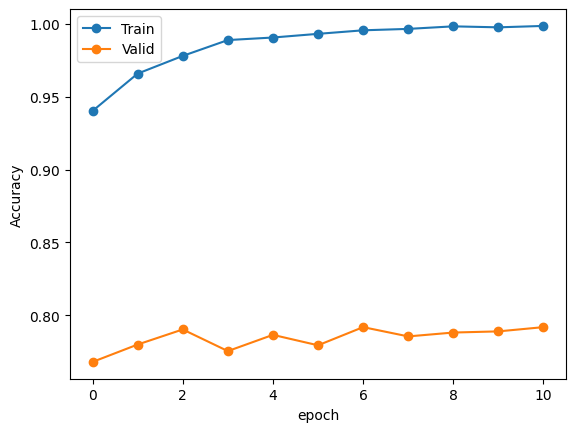

In [77]:
model_F_filter=model_train(model_algo,filtered_Fdl,Fdl_v,"F_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [78]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_T, Tdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.9  # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Tdataset = Subset(images, filter_idxs)
filtered_Tdl= DataLoader(filtered_Tdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.009064656915959347,train_accu=0.997446591199251
Epoch=0,valid_loss=0.09599418206417829,valid_accu=0.9882282819251974
0
Epoch=1,train_loss=0.008292267608403065,train_accu=0.9979572729594008
Epoch=1,valid_loss=0.11247546615594202,valid_accu=0.9867381910296528
Epoch=2,train_loss=0.004164581754270225,train_accu=0.9990211932930462
Epoch=2,valid_loss=0.11505082257041217,valid_accu=0.9879302637460885
Epoch=3,train_loss=0.0038715048709045963,train_accu=0.9988935228530088
Epoch=3,valid_loss=0.12847383649814792,valid_accu=0.9873342273878707
Epoch=4,train_loss=0.0019526302751791346,train_accu=0.9994467614265043
Epoch=4,valid_loss=0.10763031671031896,valid_accu=0.9882282819251974
4 Early stopping!


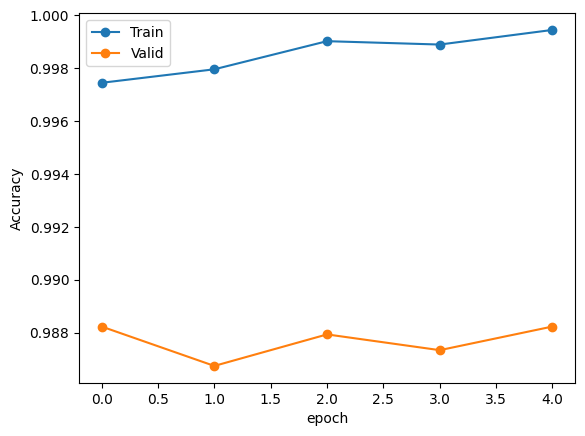

In [79]:
model_T_filter=model_train(model_algo,filtered_Tdl,Tdl_v,"T_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [80]:
F_loss_f,F_accu_f,confusion_matrix_F_train_f=evaluate_model(model_F_filter,Fdl,len(Fdataset),'F',mode='eval')
F_valid_loss_f,F_valid_accu_f,confusion_matrix_F_valid_f=evaluate_model(model_F_filter,Fdl_v,len(Fdataset_v),'F',mode='eval')

In [81]:
T_loss_f,T_accu_f,confusion_matrix_T_train_f=evaluate_model(model_T_filter,Tdl,len(Tdataset),'T',mode='eval')
T_valid_loss_f,T_valid_accu_f,confusion_matrix_T_valid_f=evaluate_model(model_T_filter,Tdl_v,len(Tdataset_v),'T',mode='eval')

In [82]:
total_train_loss_f,total_train_accu_f,confusion_matrix_total_train_f,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T_filter,model_F_filter,model_decision)
total_valid_loss_f,total_valid_accu_f,confusion_matrix_total_valid_f,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T_filter,model_F_filter,model_decision)

In [83]:
train_losses=[train_loss,decision_loss,T_loss_f,F_loss_f,total_train_loss_f,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu_f,F_accu_f,total_train_accu_f,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss_f,F_valid_loss_f,total_valid_loss_f,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu_f,F_valid_accu_f,total_valid_accu_f,total_valid_accu_d]

In [84]:
model_algos=['Model_0','Model_Decision',"Model_T_f","Model_F_f","Total_Model_f",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'targetF={targetF}')
df

targetF=[3, 5, 2, 4]


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.085637,0.973029,0.290597,0.904900
1,Model_Decision,0.214510,0.923800,0.274467,0.883500
2,Model_T_f,0.008859,0.997702,0.093655,0.988526
3,Model_F_f,0.029090,0.992538,0.816913,0.782931
4,Total_Model_f,0.022351,0.994600,0.370943,0.913600
5,Total_Model_without_decision,0.021483,0.994486,0.322093,0.914100
